In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay


In [ ]:
df = pd.read_excel("DIGI_PAY_NEW.xlsx")


In [ ]:
df = df[df['fin2'].isin([1,2])]
df = df[df['fin24c'].isin([1,2])]
df = df[df['fin30'].isin([1,2])]
df = df[df['fin32'].isin([1,2])]

df = df.dropna()


In [ ]:
df['female'] = df['female'].replace({1:1, 2:0})
df['urbanicity'] = df['urbanicity'].replace({1:0, 2:1})
df['emp_in'] = df['emp_in'].replace({1:1, 2:0})
df['fin2'] = df['fin2'].replace({1:1, 2:0})
df['fin24c'] = df['fin24c'].replace({1:1, 2:0})
df['fin30'] = df['fin30'].replace({1:1, 2:0})
df['Ffin32'] = df['fin32'].replace({1:1, 2:0})


In [ ]:
df = pd.get_dummies(df, columns=['inc_q','educ'], drop_first=True)


In [ ]:
y = df['anydigpayment']
X = df.drop(columns=['anydigpayment'])


In [ ]:
selector_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=2000
)

selector_model.fit(X, y)

model = SelectFromModel(selector_model, prefit=True)

X_selected = model.transform(X)

selected_features = X.columns[model.get_support()]

print("Selected Variables:")
print(selected_features)


Selected Variables:
Index(['female', 'age', 'emp_in', 'urbanicity', 'account_mob', 'account',
       'dig_account', 'saved', 'pay_utilities', 'fin2', 'con1', 'internet_use',
       'fin24c', 'fin30', 'borrowed', 'Ffin32', 'inc_q_2', 'inc_q_3',
       'inc_q_4', 'inc_q_5', 'educ_3'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


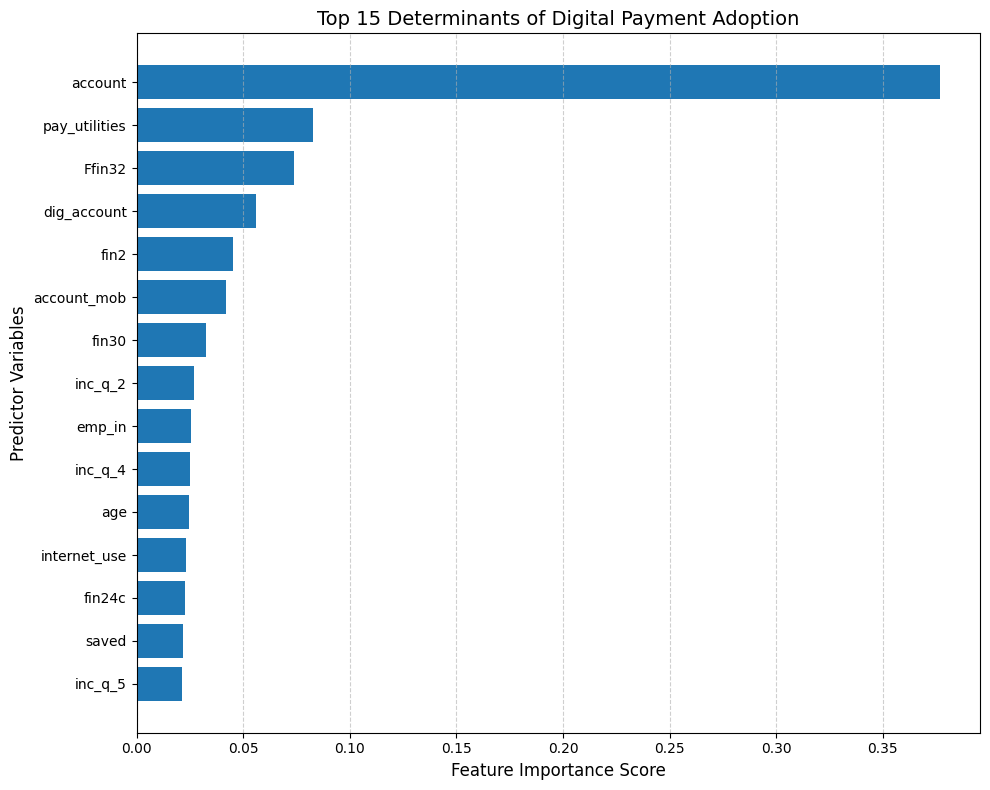

In [ ]:
import matplotlib.pyplot as plt

# Select Top 15 Features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Predictor Variables", fontsize=12)
plt.title("Top 15 Determinants of Digital Payment Adoption",
          fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier



In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42
    ),


    "SVM": SVC(
        kernel='rbf',
        probability=True
    )
}


In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}


In [ ]:
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_selected,
        y,
        cv=5,
        scoring=scoring,
        return_train_score=False
    )

    results.append({
        "Model": name,
        "Accuracy Mean": scores['test_accuracy'].mean(),
        "Accuracy Std": scores['test_accuracy'].std(),
        "F1 Mean": scores['test_f1'].mean(),
        "AUC Mean": scores['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results)

# Sort by AUC (best performance metric)
results_df = results_df.sort_values(by="AUC Mean", ascending=False)

print(results_df)


                 Model  Accuracy Mean  Accuracy Std   F1 Mean  AUC Mean
2    Gradient Boosting       0.800246      0.024653  0.778095  0.889381
3              XGBoost       0.779146      0.025331  0.765759  0.881740
0  Logistic Regression       0.782181      0.030279  0.769009  0.881215
1        Random Forest       0.791196      0.022716  0.778456  0.879827
4                  SVM       0.623543      0.037446  0.617783  0.703399


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_selected, y)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF AUC: 0.8906362760897764


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_selected, y)

print("Best XGB Parameters:", xgb_grid.best_params_)
print("Best XGB AUC:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGB Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 400, 'subsample': 1}
Best XGB AUC: 0.8918347639309252


In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Best CV AUC": [
        rf_grid.best_score_,
        xgb_grid.best_score_
    ]
})

final_results = final_results.sort_values(by="Best CV AUC", ascending=False)

print(final_results)


           Model  Best CV AUC
1        XGBoost     0.891835
0  Random Forest     0.890636


In [ ]:
best_xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

best_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.81
AUC Score: 0.887979797979798

Confusion Matrix:
[[75 15]
 [23 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        90
           1       0.85      0.79      0.82       110

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



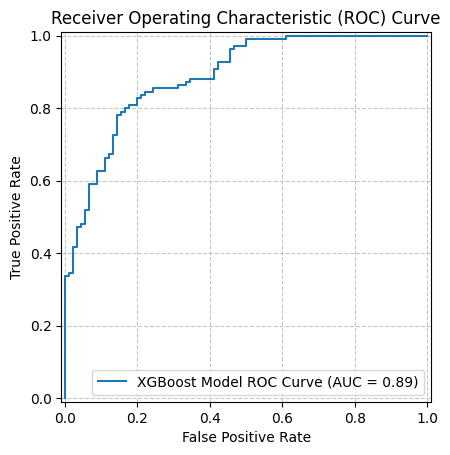

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create the ROC curve display
roc_display = RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name="XGBoost Model ROC Curve"
)

# Add title and labels
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

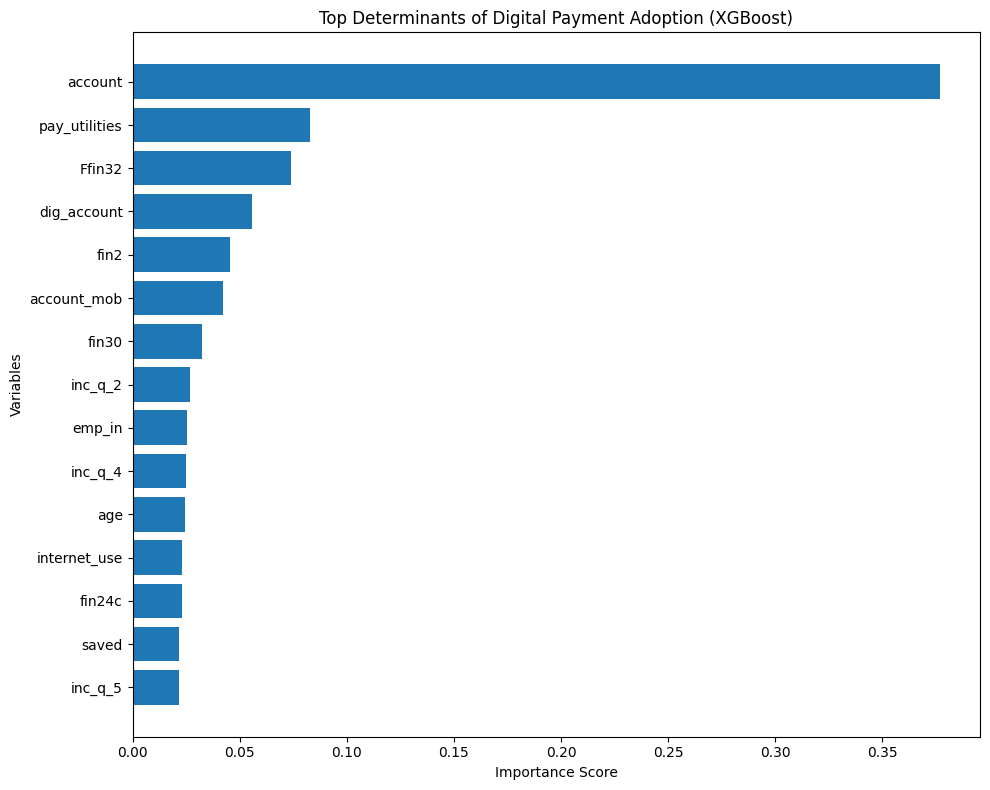

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Top 15
top_n = 15
plt.figure(figsize=(10,8))

plt.barh(
    importance_df['Feature'][:top_n][::-1],
    importance_df['Importance'][:top_n][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Variables")
plt.title("Top Determinants of Digital Payment Adoption (XGBoost)")
plt.tight_layout()
plt.show()
